In [ ]:
import yaml
import numpy as np
from TraceSimulator import LongTraceSimulator
import zstandard as zstd
from pathlib import Path
from tqdm import tqdm
import math
import os

# -------------------
# Load simulator config (one dict, reuseable)
# -------------------
def read_yaml_to_dict(file_path):
    with open(file_path, "r") as file:
        config_dict = yaml.safe_load(file)
    return config_dict

CONFIG_PATH = "/home/dwong/DELight_mtr/trigger_study/archive/wk24/training_config.yaml"
CONFIG = read_yaml_to_dict(CONFIG_PATH)
lts = LongTraceSimulator(CONFIG)


The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


In [14]:


traces, pos = lts.generate(
    E=1000, x=None, y=None, z=None,
    type_recoil='NR',
    phonon_only=False,
    no_noise=False,
    quantize=True,
    return_signal_mask=False,
    route_all_signal_to_ch0=False,
)

/home/dwong/software/TraceSimulator/TraceSimulator/LongTraceSimulator.py:205: RuntimeWarning: overflow encountered in exp
  self.template = np.concatenate([(np.exp((xs - self.trigger_time) / self.tau_rise))[xs <= self.trigger_time], (np.exp(-(xs - self.trigger_time) / self.tau_decay))[xs > self.trigger_time]])


In [4]:
traces.shape

(1, 56, 150000)

In [12]:
import matplotlib.pyplot as plt
import numpy as np

def plot_traces(traces, fs=3_906_250, offset_step=70, title="QP Traces"):
    # Handle input shapes
    if traces.ndim == 3 and traces.shape[0] == 1:
        traces = traces[0]

    num_channels, num_samples = traces.shape
    time_ms = np.arange(num_samples) / fs * 1000  # Time in ms

    plt.figure(figsize=(18, 12))

    for i in range(num_channels):
        color = 'orange' if i > 18 else 'tab:blue'
        y = traces[i] + i * offset_step
        plt.plot(time_ms, y, lw=0.4, color=color)

        # Add channel index label near the start of each trace
        plt.text(
            time_ms[0] - 0.05 * time_ms[-1],  # small shift to the left
            y[0],
            f"{i}",
            va="center",
            ha="right",
            fontsize=9,
            color=color,
            fontweight="bold"
        )

    plt.xlabel("Time [ms]", fontsize=16)
    plt.ylabel("Offset ADC counts", fontsize=16)
    plt.title(title, fontsize=18)
    plt.xlim(0, time_ms[-1])
    plt.ylim(-10, offset_step * (num_channels + 1))
    plt.yticks([])

    plt.tight_layout()
    plt.show()


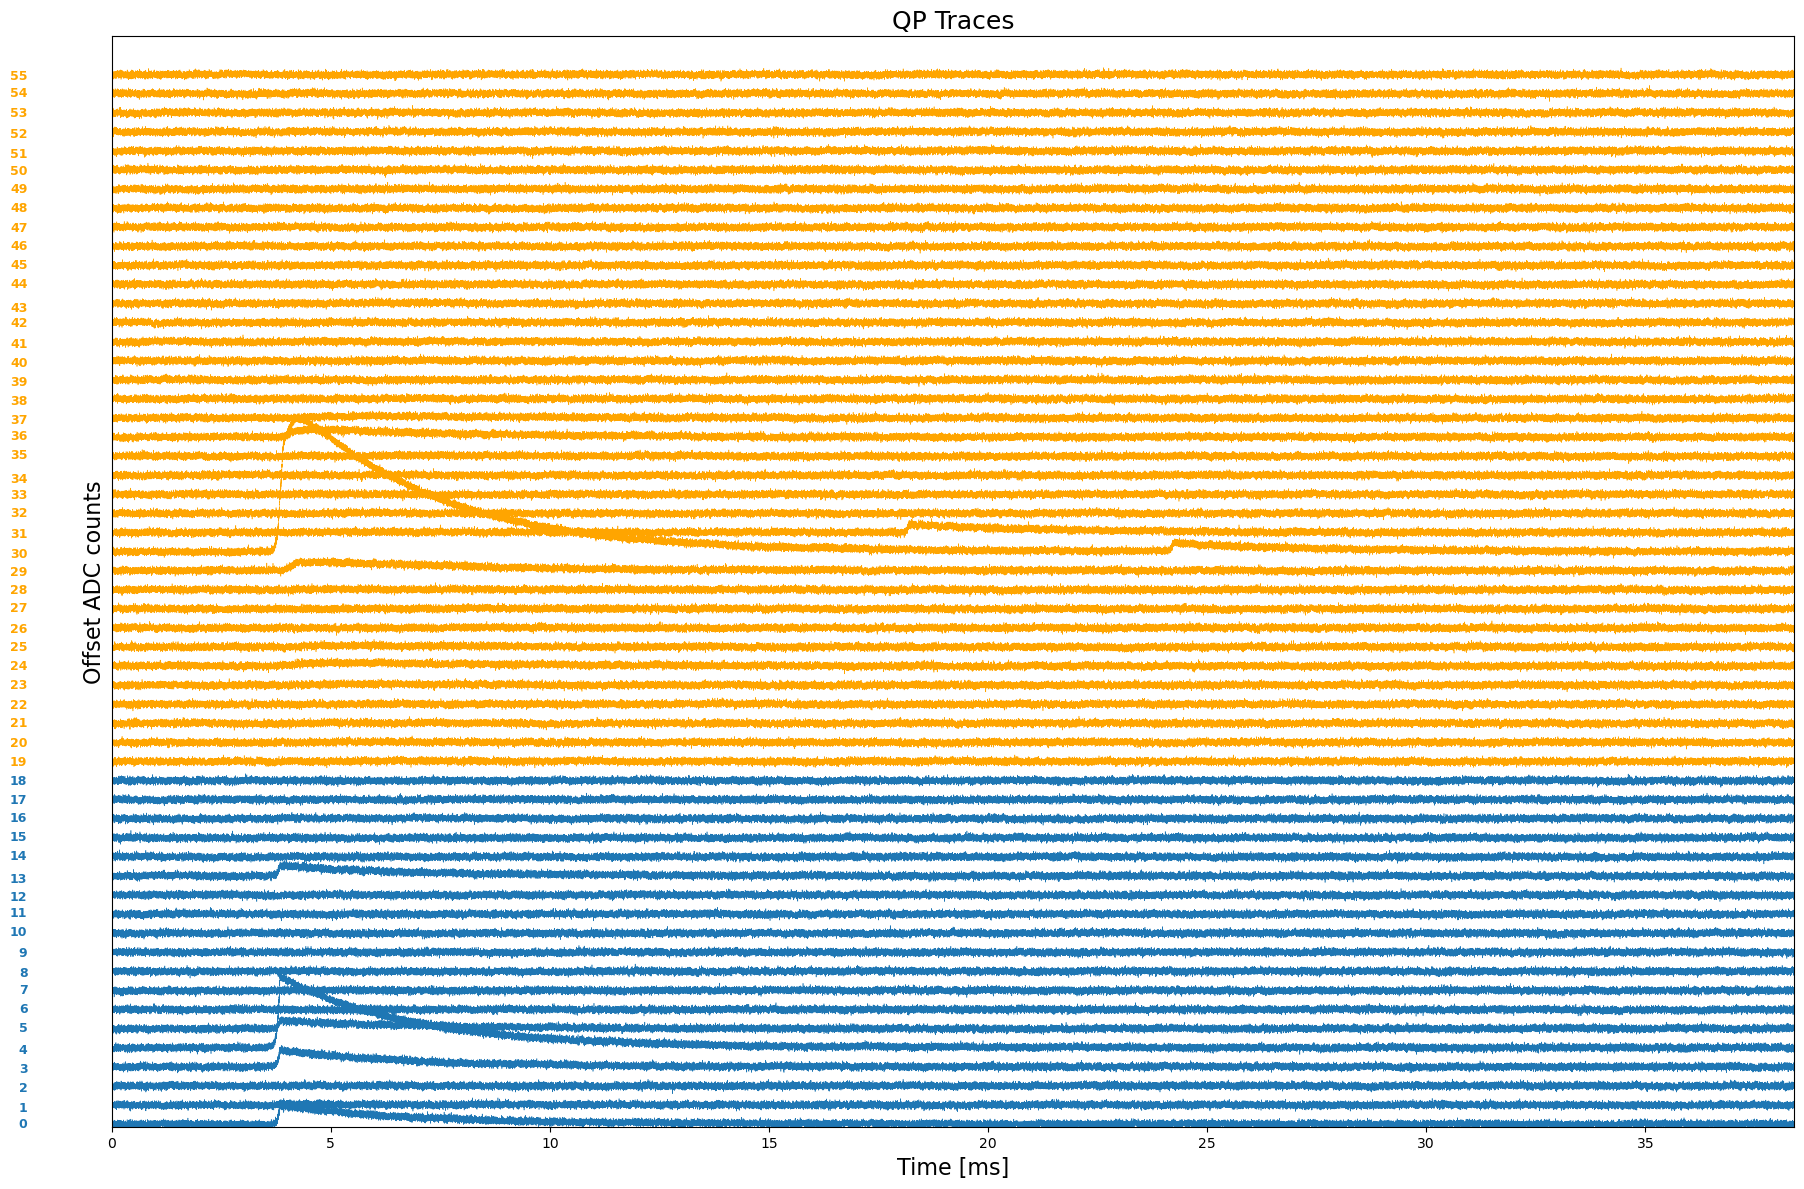

In [15]:
plot_traces(traces)